# The tasuki gap — does an unfilled gap really mean the trend has more room? 🕳️🕯️
### A classic Japanese candlestick **continuation** pattern, measured on 21.5 years of real tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Predicts_continuation%3F: Busted](https://img.shields.io/badge/Predicts_continuation%3F-Busted-8b949e?style=flat-square)

Open a candlestick book and you'll meet the **tasuki gap**: a market gaps in the direction it's trending, then takes a small breather — a candle of the opposite color pokes back toward the gap, but **can't quite close it**. The lore reads this as good news for the trend: if the pullback couldn't even close a small gap, the move still has fuel left, and it should **resume**. There's an upside version (bullish, go long) and a downside mirror (bearish, go short).

So we did the boring, honest thing: found **every** tasuki gap — both flavors — in a basket of 30 big US stocks + SPY over 21.5 years, and measured what actually happened next.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the Bonferroni correction? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name liquid large-cap + SPY** basket (names still trading today), so this carries **survivorship** in both directions — it excludes firms whose uptrend never resumed (they delisted) and, symmetrically, firms that never stopped falling. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tasuki_gap import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(allow_fetch=False, asof="2026-06-30")
else:
    PANEL = None
print("real basket cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'n_names': 30, 'fp_quantlab': '8af479f8c79c', 'fp_basket': 'aa438a4d53ea', 'total_bars': 162180, 'h1': (1, 1277, 656, 621, 0.007, 0.0, 48, 50, 0.15, 0.15, 0.15, 0.429, -0.094, -0.194), 'h5': (5, 1273, 655, 618, -0.259, 0.0, 48, 50, -2.4, -2.34, -2.33, 0.995, -0.364, -0.464), 'h10': (10, 1269, 652, 617, -0.189, 0.0, 49, 50, -1.38, -1.3, -1.29, 0.924, -0.298, -0.398), 'h20': (20, 1267, 651, 616, -0.011, 0.0, 50, 50, -0.06, -0.05, -0.05, 0.585, -0.131, -0.231), 'hit_wilson': {1: (45.7, 51.2), 5: (44.9, 50.4), 10: (46.4, 51.9), 20: (47.6, 53.1)}, 'split': {1: (-0.0, -0.5, 656, 0.014, 0.61, 621), 5: (0.15, -0.72, 655, -0.692, -2.58, 618), 10: (0.518, -0.05, 652, -0.935, -1.98, 617), 20: (1.235, 0.5, 651, -1.328, -0.8, 616)}, 'strict': [(1, 472, 244, 228, -0.007, -0.09, -0.09, 0.548, -0.108), (5, 469, 243, 226, -0.231, -1.2, -1.24, 0.927, -0.335), (10, 467, 241, 226, -0.186, -0.69, -0.65, 0.812, -0.296), (20, 467, 241, 226, 0.271, 0.68, 0.68, 0.233, 0.151)], 'trend': [(1, 616, 349, 267, 0.092, 1.31, 1.45, 0.057, -0.009), (5, 614, 348, 266, -0.358, -2.03, -2.03, 0.998, -0.462), (10, 612, 347, 265, -0.502, -2.36, -2.34, 0.998, -0.611), (20, 612, 347, 265, -0.435, -1.51, -1.54, 0.979, -0.552)], 'bonf_k': 30, 'bonf_z': 3.14, 'bonf_survive': 0, 'bonf_top': [('MRK', 49, -1.683, -2.15), ('CSCO', 44, -0.843, -1.89), ('SPY', 50, -0.504, -1.73)], 'syn_null_mean': -0.41, 'syn_null_sd': 1.12, 'syn_null_fire': 1, 'syn_null_n': 20, 'syn': [(0.0, 601, 599, -0.104, -0.76, -0.82, 50), (0.012, 593, 591, 1.119, 8.06, 8.6, 65), (0.02, 593, 591, 1.929, 13.85, 14.85, 72)]}


real basket cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| After a tasuki gap, does the trend actually resume? | **No — not in any way we can certify.** Trade in the predicted direction the next morning and, across 1–20 days, you're roughly flat-to-losing once compared fairly to an ordinary day. |
| Is there at least a hint of continuation somewhere? | **The opposite, mildly.** At 5 and 10 days the downside (bearish) version actually shows a small **reversal** — shorting after it loses money relative to shorting anything else in the basket. Not certified enough to trade, but it's the wrong-way surprise in this whole story. |
| Does the picture-perfect version (a true, full-range gap, no overlap at all) work better? | **No.** It doesn't sharpen anything — the strict shape is just rarer. |
| What if I only count patterns that genuinely continue an already-established trend? | **Still nothing — if anything, slightly worse.** |
| Does any single stock secretly carry the pattern? | **No.** Checked individually across all 30 names with enough events, using a stricter statistical bar (so one lucky name can't pass as "the" signal), **0/30** clear it. |

> A gap that stays open doesn't mean the trend has "fuel left" — on the tape it means almost nothing at all, and shorting the down-flavor into it **loses money**.

## 1 · The claim

> *"The **tasuki gap** is a continuation signal. In an uptrend: a white candle gaps up, another white candle gaps up again, and then a small black candle opens inside that second candle and pulls back — but it **can't close the gap**. If the sellers couldn't even erase a fresh gap, the buyers still have the upper hand, and the rally resumes. The downside tasuki gap is the exact bearish mirror."*

This is straight out of Steve Nison's *Japanese Candlestick Charting Techniques* (the book that brought candles to the West) and is catalogued across the standard candlestick references as one of the older continuation figures. We measure it independently, on our own basket and protocol, and ask the only question that matters: **does the trend actually keep going?**

## 2 · So what?

If the tasuki gap really predicted continuation, it would be a genuinely useful, fairly common signal — unlike some of the desk's rarer three-candle patterns, tasuki gaps show up often enough (about 1,270 times in our basket) to actually build a systematic strategy around, if the edge were real.

But there's a trap built into the shape itself: a gap plus a quick pullback candle is *exactly* the setup short-horizon mean-reversion research warns about. A market that just gapped hard and is already being faded a little might keep fading, not resume — the opposite of what the folklore promises. We'll see which force wins, and — just as important — whether any apparent edge is *real* trend-following force or just the basket's own ordinary drift dressed up as a pattern.

## 3 · How would we even know?

We take a fixed **30-name** basket of liquid US large-caps + **SPY** and scan every daily bar from **2005-01-03** to **2026-06-30** (21.5 years). For each name we flag **every** tasuki gap with a precise OHLC rule — both the upside (two white candles gapping up, then a black pullback candle that opens inside the second body and closes back inside the gap without filling it) and the downside mirror. Then, with **no cheating**:

1. **Wait for the close** that confirms the pullback candle.
2. **Enter the next morning's open** (one day's lag — you can't trade a bar still forming) and hold **1, 5, 10, or 20** trading days, in the **predicted trend direction** (long for upside tasuki, short for downside).
3. **Compare fairly** — not to zero (a naive comparison is fooled by the market's own drift, and confuses long and short bets), but to what the *same basket* earns on an unconditional day, matched to the same direction, and to thousands of random "fake signal" picks in the same long/short mix. If riding the trend after a tasuki gap beats the everyday tide, the legend is real. If it doesn't, continuation is a myth.

## 4 · The teardown — let's actually look

**First, the headline.** Here's the trend-signed return after a tasuki gap, at each horizon, next to what the *same basket* earns on an ordinary (unconditional) day in the same direction. A real "continuation" signal would show the pattern's bar **beating** the baseline, in green.

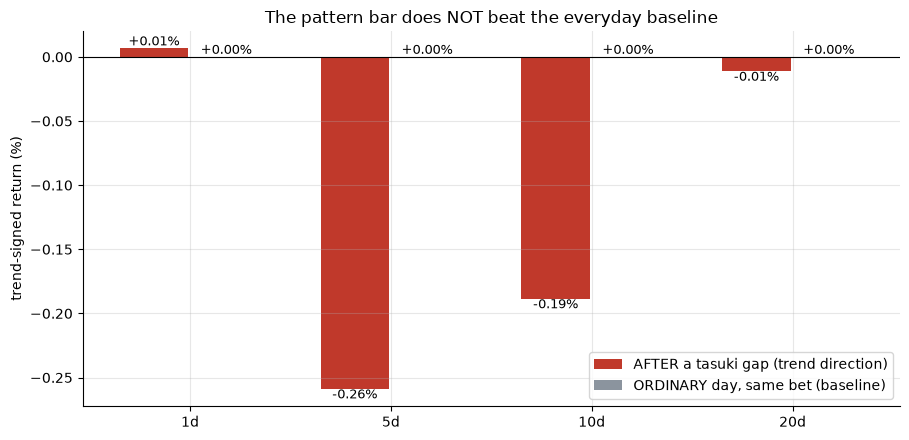

after tasuki gap: {'1d': 0.007, '5d': -0.259, '10d': -0.189, '20d': -0.011}
ordinary day (same bet): {'1d': 0.0, '5d': 0.0, '10d': 0.0, '20d': 0.0}


In [2]:
hs = [1, 5, 10, 20]
if HAVE_REAL:
    rows = {h: st.summarize(PANEL, h, placebo=False) for h in hs}
    means = [rows[h]['mean']*100 for h in hs]
    base  = [rows[h]['base_mean']*100 for h in hs]
else:
    keys = ['h1','h5','h10','h20']
    means = [R[k][4] for k in keys]; base = [R[k][5] for k in keys]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.5))
ax.bar(x-.18, means, .34, color=RED, label='AFTER a tasuki gap (trend direction)')
ax.bar(x+.18, base, .34, color=GREY, label='ORDINARY day, same bet (baseline)')
for i,v in enumerate(means): ax.annotate(f'{v:+.2f}%',(i-.18,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
for i,v in enumerate(base): ax.annotate(f'{v:+.2f}%',(i+.18,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('trend-signed return (%)')
ax.set_title('The pattern bar does NOT beat the everyday baseline')
ax.legend(); plt.tight_layout(); plt.show()
print('after tasuki gap:', {f'{h}d': round(m,3) for h,m in zip(hs,means)})
print('ordinary day (same bet):', {f'{h}d': round(b,3) for h,b in zip(hs,base)})

At 5 days the pattern trade is **-0.26%** — *negative* — against **+0.00%** for an ordinary day's same-direction bet. The pattern doesn't add continuation information; if anything it briefly underperforms doing nothing special. The "significant-looking" number you'd get by comparing the pattern to **zero** — ignoring which direction each trade actually is — is a mirage created by the basket's own drift, not the gap.

**Is it the long side or the short side dragging this down?** Tasuki gaps come in two flavors — let's split them.

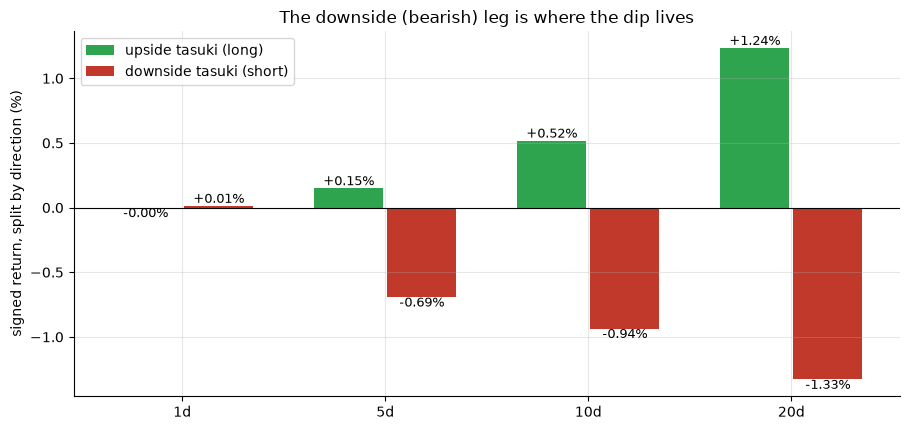

upside (long): {'1d': -0.0, '5d': 0.15, '10d': 0.518, '20d': 1.235}
downside (short): {'1d': 0.014, '5d': -0.692, '10d': -0.935, '20d': -1.328}


In [3]:
if HAVE_REAL:
    up_m = [rows[h]['up_mean']*100 for h in hs]
    dn_m = [rows[h]['down_mean']*100 for h in hs]
else:
    up_m = [R['split'][h][0] for h in hs]; dn_m = [R['split'][h][3] for h in hs]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.18, up_m, .34, color=GREEN, label='upside tasuki (long)')
ax.bar(x+.18, dn_m, .34, color=RED, label='downside tasuki (short)')
for i,v in enumerate(up_m): ax.annotate(f'{v:+.2f}%',(i-.18,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
for i,v in enumerate(dn_m): ax.annotate(f'{v:+.2f}%',(i+.18,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('signed return, split by direction (%)')
ax.set_title('The downside (bearish) leg is where the dip lives')
ax.legend(); plt.tight_layout(); plt.show()
print('upside (long):', {f'{h}d': round(v,3) for h,v in zip(hs,up_m)})
print('downside (short):', {f'{h}d': round(v,3) for h,v in zip(hs,dn_m)})

The **upside** tasuki (long) is small and bounces around zero at every horizon — never a real edge, but also never a real problem. The **downside** tasuki (short) is where the story lives: at 5 days it's **-0.69%**, a mild **reversal** — shorting into a downside tasuki loses relative to shorting anything else in the basket. The market couldn't close the gap, but instead of *falling further* it tended to bounce.

**Could it just be luck?** Let's pit the real signal against thousands of **fake** ones matched to the same long/short mix: pick the same number of random days, flip a weighted coin, and see how the real pattern's return stacks up.

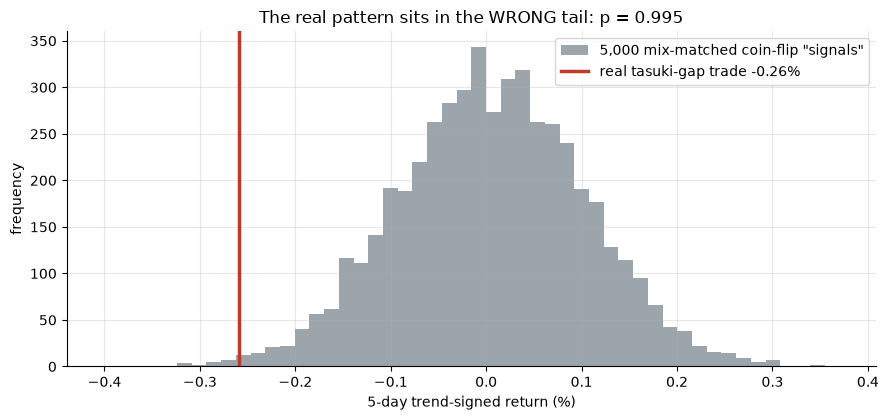

observed -0.26%   share of random fakes that beat it: p = 0.995


In [4]:
if HAVE_REAL:
    ev = st.collect_events(PANEL, 5)
    n_up = int((ev['direction']>0).sum()); n_dn = int((ev['direction']<0).sum())
    obs = float(ev['signed_ret'].mean())
    pl = st.placebo_pvalue(PANEL, 5, n_up, n_dn, obs, n_draws=5000)
    draws = pl['draws']*100; obsp = obs*100; pval = pl['p_value']
else:
    obsp = R['h5'][4]; pval = R['h5'][11]
    rng = np.random.default_rng(693); draws = rng.normal(0.0, 0.34, 5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='5,000 mix-matched coin-flip "signals"')
ax.axvline(obsp, c=RED, lw=2.5, label=f'real tasuki-gap trade {obsp:+.2f}%')
ax.set_xlabel('5-day trend-signed return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real pattern sits in the WRONG tail: p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obsp:+.2f}%   share of random fakes that beat it: p = {pval:.3f}')

With placebo *p* = **0.995**, roughly 99.5% of random, undirected coin flips in the same long/short mix would have done *better* than the real pattern. That's the opposite of a genuine edge — it's a mild statistical curiosity, not something to trade.

**Does the picture-perfect version save it?** Maybe an overlapping, casual gap is noise but the strict, true full-range gap — or only counting patterns that follow a *genuine*, already-established trend — is the real deal. Let's check both stricter recipes against a fair (direction-matched-base) comparison.

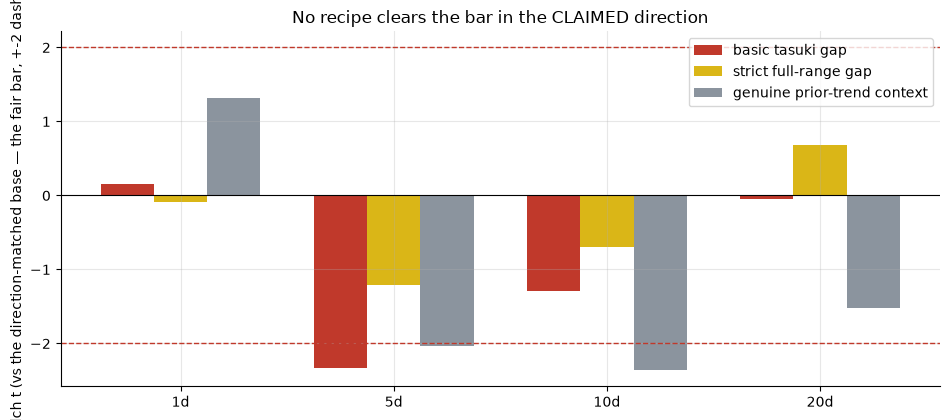

basic t: [0.15, -2.33, -1.29, -0.05]
strict t: [-0.09, -1.2, -0.69, 0.68]
trend t: [1.31, -2.03, -2.36, -1.51]


In [5]:
if HAVE_REAL:
    basic  = [st.summarize(PANEL, h, placebo=False)['t_welch'] for h in hs]
    strict = [st.summarize(PANEL, h, placebo=False, true_range_gap=True)['t_welch'] for h in hs]
    trend  = [st.summarize(PANEL, h, placebo=False, require_trend=True)['t_welch'] for h in hs]
else:
    basic  = [R[k][10] for k in ['h1','h5','h10','h20']]
    strict = [s[5] for s in R['strict']]; trend = [t[5] for t in R['trend']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.25, basic, .25, color=RED, label='basic tasuki gap')
ax.bar(x,      strict,.25, color=AMBER, label='strict full-range gap')
ax.bar(x+.25,  trend, .25, color=GREY, label='genuine prior-trend context')
ax.axhline(0, c='k', lw=.8); ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Welch t (vs the direction-matched base — the fair bar, +-2 dashed)')
ax.set_title('No recipe clears the bar in the CLAIMED direction')
ax.legend(); plt.tight_layout(); plt.show()
print('basic t:', [round(b,2) for b in basic]); print('strict t:', [round(s,2) for s in strict]); print('trend t:', [round(t,2) for t in trend])

No bar in that chart pokes above the dashed **+2** line — the direction the folklore needs — under any of the three recipes. If anything, requiring a genuine prior trend makes the dip at 5 and 10 days *deeper*, the exact opposite of what a "purer, more authentic" continuation setup should do.

## 5 · The verdict

- **Signal — None.** Measured fairly (against the basket's own unconditional day, matched to direction, not against zero), the trend-signed tasuki-gap trade never certifies a continuation at any horizon. The only reading past ±2 (5-day) points **backwards** — a mild reversal on the downside leg. No single stock secretly carries it either — **0/30** individual tickers clear a corrected bar. There's no continuation edge.
- **Tradability — Mirage.** It's flat-to-negative **before** costs; once you add the spread and short borrow it's worse at every horizon. Nothing to deploy.
- **"Predicts continuation"? — Busted.** The famous "gap can't be closed, the trend has fuel left" reading doesn't survive contact with the tape once you compare it to an ordinary day, in the same direction.

## 6 · Could you actually trade it? — no, and here's the kicker

The trade is already flat-to-negative gross. Now add the real-world frictions — the spread paid on the round trip, plus borrow to hold the short leg. The bars only sink further.

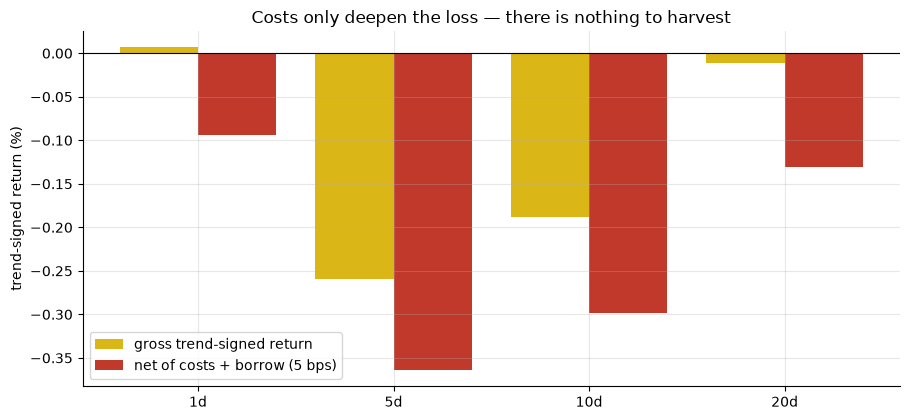

net trend-signed return by horizon: {'1d': -0.094, '5d': -0.364, '10d': -0.298, '20d': -0.131}


In [6]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    n5 = [float(st.event_net_returns(st.collect_events(PANEL, h), h, cost_bps=5.0).mean())*100 for h in hs]
else:
    keys = ['h1','h5','h10','h20']
    g  = [R[k][4] for k in keys]; n5 = [R[k][12] for k in keys]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=AMBER, label='gross trend-signed return')
ax.bar(x+.2, n5, .4, color=RED, label='net of costs + borrow (5 bps)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('trend-signed return (%)'); ax.set_title('Costs only deepen the loss — there is nothing to harvest')
ax.legend(); plt.tight_layout(); plt.show()
print('net trend-signed return by horizon:', {f'{h}d': round(v,3) for h,v in zip(hs,n5)})

At every horizon the **net** trade is more negative than the gross — e.g. **-0.36%** at 5 days. There is no window where it pays. The tasuki gap is common enough to build a strategy around if it worked — it just doesn't.

## 7 · Going further 🚪

- **Why does the naive comparison fool people?** Any trend-following bet in a drifting market looks "significant" against **zero** — with or without a tasuki gap — because long trades ride the market's own drift and short trades fight it. That's why this study's certifying test compares each event to what the *same basket* earns on an ordinary day, in the *same direction*. The [quants notebook](02_for_the_quants.ipynb) shows this trap live on a synthetic panel with a **known** zero edge.
- **The gap-pattern family.** [74-mind-the-gap](../../74-mind-the-gap/) asks the general "do gaps fill" question across all shapes; [417-island-reversal](../../417-island-reversal/) needs *two* opposite gaps predicting the opposite outcome (reversal); [455-three-methods](../../455-three-methods/) is a continuation pattern with **no gap at all** — none of them run this study's specific figure.

*Think a stricter gap, a different universe, or a clever filter turns it green? Show the **net** trend-signed return landing above the basket's own direction-matched baseline with Welch *t* ≥ 2 — then we'll talk.*